# S2 Toolkit Sanity · AUDUSD vs NZDUSD

Runnable smoke of every public S2 store routine on one Book A (forex) toy pair.
Not a hypothesis bake-off — only checks that fetch → hedge → z → half-life → health metrics → Engle-Granger discovery wire up cleanly.

**Note:** `run_cointegration_test` is discovery-only / non-PIT (fit on the loaded window). Do not call it inside a backtest loop.

## 0. Imports & Config

In [1]:
from __future__ import annotations

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from data.ingestion.equity_fetcher import fetch_ohlcv
from data.processing.s2_universe import load_s2_pools, pool_tickers
from data.processing.s2_coint_store import (
    COINT_METRICS,
    compute_coint_metrics,
    compute_half_life,
    compute_kalman_hedge_spread,
    compute_spread_zscore,
    compute_static_hedge_spread,
    run_cointegration_test,
)

UNIVERSE_LABEL = "A"  # Book A = forex

Y_TICKER = "AUDUSD=X"
X_TICKER = "NZDUSD=X"

START_DATE = "2018-01-01"
END_DATE = None

HEDGE_WINDOW = 252
Z_WINDOW = 60
HL_WINDOW = 252
ADF_WINDOW = 252
VAR_WINDOW = 60
VAR_BASELINE = 252

DELTA = 1e-4
OBS_VAR = 1e-3
BURN_IN = 30

print(f"ROOT={ROOT}")
print(f"pair: {Y_TICKER} ~ {X_TICKER}")

ROOT=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
pair: AUDUSD=X ~ NZDUSD=X


## 1. Data Loading

Read Book A tickers from `S2_POOLS` (universe A), confirm the toy pair is present, fetch daily OHLCV via `fetch_ohlcv`, then inner-join closes onto a shared `DatetimeIndex` (the store refuses silent alignment).

In [2]:
book_a = pool_tickers(load_s2_pools(UNIVERSE_LABEL))
print(f"Book {UNIVERSE_LABEL}: {book_a}")

if Y_TICKER not in book_a or X_TICKER not in book_a:
    raise ValueError(
        f"Toy pair ({Y_TICKER}, {X_TICKER}) must both appear in universe {UNIVERSE_LABEL}"
    )

panel_y = fetch_ohlcv(Y_TICKER, START_DATE, END_DATE, isAsian=False)
panel_x = fetch_ohlcv(X_TICKER, START_DATE, END_DATE, isAsian=False)

for name, panel in ((Y_TICKER, panel_y), (X_TICKER, panel_x)):
    print(
        f"{name}: shape={panel.shape}  "
        f"dates={panel['date'].min().date()} → {panel['date'].max().date()}"
    )

y_raw = panel_y.set_index(pd.to_datetime(panel_y["date"]))["close"].astype(float).sort_index()
x_raw = panel_x.set_index(pd.to_datetime(panel_x["date"]))["close"].astype(float).sort_index()
y_raw.name = Y_TICKER
x_raw.name = X_TICKER

shared = y_raw.index.intersection(x_raw.index)
dropped_y = int(len(y_raw) - len(shared))
dropped_x = int(len(x_raw) - len(shared))
print(f"inner-join drops: {Y_TICKER}={dropped_y} bars, {X_TICKER}={dropped_x} bars")

y = y_raw.loc[shared].copy()
x = x_raw.loc[shared].copy()
assert y.index.equals(x.index), "indexes must be identical before store calls"
print(f"aligned length={len(y)}  range={y.index.min().date()} → {y.index.max().date()}")
display(pd.DataFrame({"y": y, "x": x}).head())

Book A (line 0): ['AUDUSD=X', 'NZDUSD=X', 'EURUSD=X', 'GBPUSD=X', 'USDCHF=X', 'USDJPY=X']
AUDUSD=X: shape=(2242, 7)  dates=2018-01-01 → 2026-08-12
NZDUSD=X: shape=(2242, 7)  dates=2018-01-01 → 2026-08-12
inner-join drops: AUDUSD=X=0 bars, NZDUSD=X=0 bars
aligned length=2242  range=2018-01-01 → 2026-08-12


,y,x
date,,
2018-01-01,0.780214,0.711389
2018-01-02,0.780104,0.708818
2018-01-03,0.783392,0.710021
2018-01-04,0.782840,0.709019
2018-01-05,0.786380,0.715599


## 2. Data Cleaning & Engineering

Drop bars where either close is non-positive or NaN. No winsorize / floors — the store converts raw prices to logs internally via `to_log_price`.

In [3]:
ok = (
    y.notna()
    & x.notna()
    & np.isfinite(y)
    & np.isfinite(x)
    & (y > 0)
    & (x > 0)
)
n_before = len(y)
y = y.loc[ok].copy()
x = x.loc[ok].copy()
assert y.index.equals(x.index)
print(f"cleaned: {n_before} → {len(y)} bars (dropped {n_before - len(y)})")

cleaned: 2242 → 2242 bars (dropped 0)


## 3. Modeling / Signal Construction

Exercise every public store entrypoint. Spread formula everywhere: `s_t = y_t - alpha_t - beta_t * x_t` (on log prices inside the store).

`run_cointegration_test` is **discovery-only / non-PIT** — fit on the loaded window for toolkit smoke only.

In [4]:
eg = run_cointegration_test(y, x)
print("=== run_cointegration_test (discovery / non-PIT) ===")
print(f"is_cointegrated={eg.is_cointegrated}")
print(f"pvalue={eg.pvalue:.6g}  tstat={eg.tstat:.4f}  direction={eg.direction}")
print(f"alpha={eg.alpha:.6g}  beta={eg.beta:.6g}")
print(
    f"y_I(1)={eg.y_is_i1} (level_p={eg.y_adf_level_p:.4g}, diff_p={eg.y_adf_diff_p:.4g})"
)
print(
    f"x_I(1)={eg.x_is_i1} (level_p={eg.x_adf_level_p:.4g}, diff_p={eg.x_adf_diff_p:.4g})"
)
print(f"crit_values={eg.crit_values}")

=== run_cointegration_test (discovery / non-PIT) ===
is_cointegrated=False
pvalue=0.564563  tstat=-1.9303  direction=y~x
alpha=-0.0373553  beta=0.731757
y_I(1)=True (level_p=0.05458, diff_p=0)
x_I(1)=True (level_p=0.2235, diff_p=0)
crit_values={'1%': -3.901333735266317, '5%': -3.3388578646242464, '10%': -3.0463430895778063}


In [5]:
static = compute_static_hedge_spread(y, x, window=HEDGE_WINDOW)
print("=== compute_static_hedge_spread ===")
print(f"columns={list(static.columns)}")
print(f"NaNs: {static.isna().sum().to_dict()}")
last_static = static.dropna().iloc[-1]
print(
    f"last finite: alpha={last_static['alpha']:.6g}  "
    f"beta={last_static['beta']:.6g}  spread={last_static['spread']:.6g}"
)
display(static.dropna().tail())

=== compute_static_hedge_spread ===
columns=['alpha', 'beta', 'spread']
NaNs: {'alpha': 251, 'beta': 251, 'spread': 251}
last finite: alpha=0.219491  beta=1.10793  spread=0.0244861


,alpha,beta,spread
date,,,
2026-08-06,0.191259,1.058262,0.020835
2026-08-07,0.200401,1.074545,0.020438
2026-08-10,0.209992,1.091640,0.020570
2026-08-11,0.217566,1.104996,0.018872
2026-08-12,0.219491,1.107926,0.024486


In [6]:
kalman = compute_kalman_hedge_spread(
    y, x, delta=DELTA, obs_var=OBS_VAR, burn_in=BURN_IN
)
print("=== compute_kalman_hedge_spread ===")
print(f"columns={list(kalman.columns)}")
print(f"NaNs: {kalman.isna().sum().to_dict()}")
last_kf = kalman.dropna().iloc[-1]
print(
    f"last finite: alpha={last_kf['alpha']:.6g}  beta={last_kf['beta']:.6g}  "
    f"spread={last_kf['spread']:.6g}  spread_var={last_kf['spread_var']:.6g}  "
    f"z_innov={last_kf['z_innov']:.6g}"
)
display(kalman.dropna().tail())

=== compute_kalman_hedge_spread ===
columns=['beta', 'alpha', 'spread', 'spread_var', 'z_innov']
NaNs: {'beta': 30, 'alpha': 30, 'spread': 30, 'spread_var': 30, 'z_innov': 30}
last finite: alpha=0.0757551  beta=0.801762  spread=0.00561938  spread_var=0.00142801  z_innov=0.148704


,beta,alpha,spread,spread_var,z_innov
date,,,,,
2026-08-06,0.801825,0.074580,0.001666,0.001428,0.044092
2026-08-07,0.801858,0.075096,0.000395,0.001429,0.010450
2026-08-10,0.801811,0.075190,0.001859,0.001428,0.049206
2026-08-11,0.801768,0.075724,0.000113,0.001428,0.003001
2026-08-12,0.801762,0.075755,0.005619,0.001428,0.148704


In [7]:
z = compute_spread_zscore(static["spread"], window=Z_WINDOW)
hl = compute_half_life(static["spread"], window=HL_WINDOW)
metrics = compute_coint_metrics(
    static["spread"],
    metrics=None,
    adf_window=ADF_WINDOW,
    var_window=VAR_WINDOW,
    var_baseline_window=VAR_BASELINE,
)

print("=== compute_spread_zscore ===")
print(f"NaNs={int(z.isna().sum())}  last finite={z.dropna().iloc[-1]:.6g}")

print("=== compute_half_life ===")
print(f"NaNs={int(hl.isna().sum())}  finite={int(hl.notna().sum())}")
if hl.notna().any():
    print(f"last finite half-life={hl.dropna().iloc[-1]:.4g} bars")

print("=== compute_coint_metrics ===")
print(f"columns={list(metrics.columns)}  (expected {list(COINT_METRICS)})")
print(f"NaNs: {metrics.isna().sum().to_dict()}")
display(pd.DataFrame({"z": z, "half_life": hl}).join(metrics).dropna(how="all").tail())

=== compute_spread_zscore ===
NaNs=310  last finite=-1.082
=== compute_half_life ===
NaNs=286  finite=1956
last finite half-life=27.51 bars
=== compute_coint_metrics ===
columns=['adf_pvalue', 'variance_jump']  (expected ['adf_pvalue', 'variance_jump'])
NaNs: {'adf_pvalue': 502, 'variance_jump': 562}


,z,half_life,adf_pvalue,variance_jump
date,,,,
2026-08-06,-1.518236,29.045033,0.291435,0.481133
2026-08-07,-1.515375,27.705244,0.254798,0.472397
2026-08-10,-1.459168,26.010883,0.207060,0.471980
2026-08-11,-1.546072,30.229386,0.337673,0.468092
2026-08-12,-1.082005,27.509936,0.262640,0.466834


## 4. Evaluation

Plots for the toy pair, then soft PASS / FAIL / WARN checks (do not hard-abort the notebook).

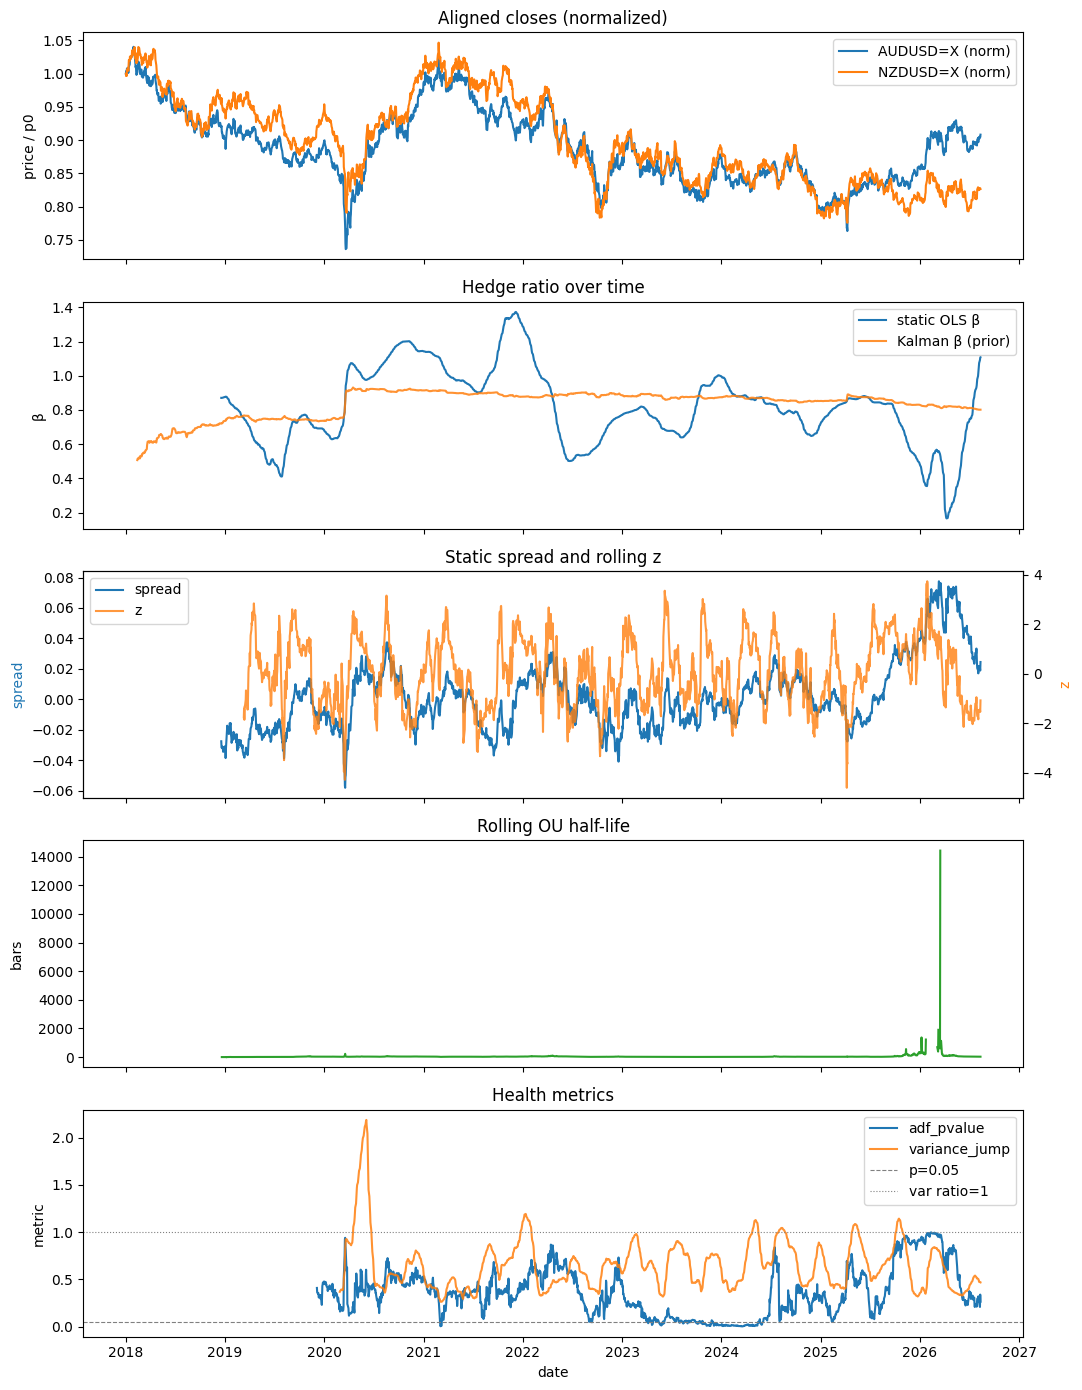

In [8]:
y_norm = y / y.iloc[0]
x_norm = x / x.iloc[0]

fig, axes = plt.subplots(5, 1, figsize=(11, 14), sharex=True)

axes[0].plot(y_norm.index, y_norm, label=f"{Y_TICKER} (norm)")
axes[0].plot(x_norm.index, x_norm, label=f"{X_TICKER} (norm)")
axes[0].set_ylabel("price / p0")
axes[0].set_title("Aligned closes (normalized)")
axes[0].legend(loc="best")

axes[1].plot(static.index, static["beta"], label="static OLS β")
axes[1].plot(kalman.index, kalman["beta"], label="Kalman β (prior)", alpha=0.85)
axes[1].set_ylabel("β")
axes[1].set_title("Hedge ratio over time")
axes[1].legend(loc="best")

ax2b = axes[2].twinx()
axes[2].plot(static.index, static["spread"], color="C0", label="spread")
ax2b.plot(z.index, z, color="C1", alpha=0.8, label="z")
axes[2].set_ylabel("spread", color="C0")
ax2b.set_ylabel("z", color="C1")
axes[2].set_title("Static spread and rolling z")
lines_a, labels_a = axes[2].get_legend_handles_labels()
lines_b, labels_b = ax2b.get_legend_handles_labels()
axes[2].legend(lines_a + lines_b, labels_a + labels_b, loc="best")

axes[3].plot(hl.index, hl, color="C2")
axes[3].set_ylabel("bars")
axes[3].set_title("Rolling OU half-life")

axes[4].plot(metrics.index, metrics["adf_pvalue"], label="adf_pvalue")
axes[4].plot(metrics.index, metrics["variance_jump"], label="variance_jump", alpha=0.85)
axes[4].axhline(0.05, color="gray", ls="--", lw=0.8, label="p=0.05")
axes[4].axhline(1.0, color="gray", ls=":", lw=0.8, label="var ratio=1")
axes[4].set_ylabel("metric")
axes[4].set_title("Health metrics")
axes[4].legend(loc="best")

axes[-1].set_xlabel("date")
fig.tight_layout()
plt.show()

In [9]:
def _check(name: str, ok: bool, detail: str = "") -> None:
    status = "PASS" if ok else "FAIL"
    suffix = f" — {detail}" if detail else ""
    print(f"[{status}] {name}{suffix}")


def _warn(name: str, detail: str = "") -> None:
    suffix = f" — {detail}" if detail else ""
    print(f"[WARN] {name}{suffix}")


print("=== Sanity checks ===")

_check("EG finite pvalue", bool(np.isfinite(eg.pvalue)), f"p={eg.pvalue}")

static_warm = static["spread"].iloc[HEDGE_WINDOW:]
_check(
    "static spread finite after warm-up",
    bool(static_warm.notna().any()),
    f"finite={int(static_warm.notna().sum())}/{len(static_warm)}",
)

kalman_warm = kalman["spread"].iloc[BURN_IN:]
_check(
    "Kalman spread finite after burn-in",
    bool(kalman_warm.notna().any()),
    f"finite={int(kalman_warm.notna().sum())}/{len(kalman_warm)}",
)

hl_warm = hl.iloc[HL_WINDOW - 1 :]
if hl_warm.notna().any():
    _check(
        "half-life finite after window",
        True,
        f"finite={int(hl_warm.notna().sum())} last={hl_warm.dropna().iloc[-1]:.4g}",
    )
else:
    _warn("half-life all NaN after window (pair may not look mean-reverting on this sample)")

_check(
    "coint metrics columns",
    list(metrics.columns) == list(COINT_METRICS),
    f"got={list(metrics.columns)}",
)

# Prefix stability (no look-ahead): truncated run matches full run on overlap
cut = 20
static_pref = compute_static_hedge_spread(y.iloc[:-cut], x.iloc[:-cut], window=HEDGE_WINDOW)
shared_idx = static.index.intersection(static_pref.index)
a = static.loc[shared_idx, "spread"]
b = static_pref.loc[shared_idx, "spread"]
both = a.notna() & b.notna()
if both.any():
    max_abs = float(np.nanmax(np.abs(a.loc[both].to_numpy() - b.loc[both].to_numpy())))
    _check("prefix-stable static spread", max_abs < 1e-10, f"max|Δ|={max_abs:.3g}")
else:
    _warn("prefix-stability skipped (no overlapping finite spreads)")

print("Done.")

=== Sanity checks ===
[PASS] EG finite pvalue — p=0.5645628830905686
[PASS] static spread finite after warm-up — finite=1990/1990
[PASS] Kalman spread finite after burn-in — finite=2212/2212
[PASS] half-life finite after window — finite=1956 last=27.51
[PASS] coint metrics columns — got=['adf_pvalue', 'variance_jump']
[PASS] prefix-stable static spread — max|Δ|=0
Done.
